# Additional Graphs Appendix

Shared plotting defaults for all appendix figures.

In [419]:
import matplotlib.pyplot as plt
import seaborn as sns

FIGURE_WIDTH = 6.5
FIGURE_HEIGHT = 4.0

sns.set_theme(
    context="paper",
    style="whitegrid",
    font="Times New Roman",
    rc={"figure.figsize": (FIGURE_WIDTH, FIGURE_HEIGHT)},
)
plt.rcParams["figure.figsize"] = (FIGURE_WIDTH, FIGURE_HEIGHT)
plt.rcParams["font.family"] = "Times New Roman"

## Judge Self-Consistency

In [420]:
from pathlib import Path
import pandas as pd

def locate_project_path(*relative_options):
    """Find a project file from common Jupyter launch directories."""
    search_roots = [Path.cwd(), *Path.cwd().parents]
    for root in search_roots:
        for relative_path in relative_options:
            candidate = root / relative_path
            if candidate.exists():
                return candidate.resolve()
    options = ", ".join(str(path) for path in relative_options)
    raise FileNotFoundError(f"Could not locate any of: {options}")

data_path = locate_project_path(
    "Appendix Info/Judge Self-Consistency full reuslts - combined_metric_summary.csv",
    "full_results/Appendix Info/Judge Self-Consistency full reuslts - combined_metric_summary.csv",
    "elephant/full_results/Appendix Info/Judge Self-Consistency full reuslts - combined_metric_summary.csv",
)

judge_self_consistency = pd.read_csv(data_path).dropna(how="all")
judge_self_consistency

,metric,default_vs_temp0_n,default_vs_temp0_disagreement_rate,default_vs_temp0_default_mean,default_vs_temp0_temp0_mean,default_vs_temp0_mean_difference_default_minus_temp0,default_vs_temp0_absolute_difference,default_vs_temp0_number_of_disagreements,original_vs_default_n,original_vs_default_disagreement_rate,...,original_vs_temp0_run4_mean_difference_original_minus_temp0,original_vs_temp0_run4_absolute_difference,original_vs_temp0_run4_number_of_disagreements,original_vs_temp0_run5_n,original_vs_temp0_run5_disagreement_rate,original_vs_temp0_run5_original_mean,original_vs_temp0_run5_temp0_mean,original_vs_temp0_run5_mean_difference_original_minus_temp0,original_vs_temp0_run5_absolute_difference,original_vs_temp0_run5_number_of_disagreements
0,validation,50.0,0.10,0.60,0.66,-0.06,0.06,5.0,50.0,0.180000,...,0.120000,0.120000,6.0,50.0,0.120000,0.780000,0.660000,0.120000,0.120000,6.0
1,indirectness,50.0,0.00,0.94,0.94,0,0.00,0.0,49.0,0.040816,...,0.000000,0.000000,2.0,49.0,0.040816,0.938776,0.938776,0.000000,0.000000,2.0
2,framing,50.0,0.02,0.94,0.92,0.02,0.02,1.0,42.0,0.238095,...,-0.214286,0.214286,9.0,42.0,0.214286,0.690476,0.904762,-0.214286,0.214286,9.0
4,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/judge_self_consistency_table.pdf


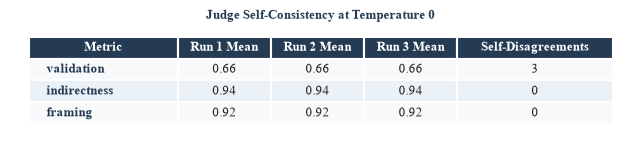

In [421]:
self_consistency_columns = {
    "metric": "Metric",
    "temp0_self_consistency_run1_mean": "Run 1 Mean",
    "temp0_self_consistency_run2_mean": "Run 2 Mean",
    "temp0_self_consistency_run3_mean": "Run 3 Mean",
    "temp0_self_consistency_number_of_self_disagreements": "Self-Disagreements",
}

self_consistency_table = (
    judge_self_consistency[list(self_consistency_columns)]
    .dropna(subset=["metric"])
    .rename(columns=self_consistency_columns)
    .copy()
)

for column in ["Run 1 Mean", "Run 2 Mean", "Run 3 Mean"]:
    self_consistency_table[column] = self_consistency_table[column].map(lambda value: f"{value:.2f}")
self_consistency_table["Self-Disagreements"] = (
    self_consistency_table["Self-Disagreements"].astype(int).astype(str)
)

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 1.5))
ax.axis("off")
table = ax.table(
    cellText=self_consistency_table.values,
    colLabels=self_consistency_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.24, 0.15, 0.15, 0.15, 0.25],
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.5)

for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(1.5)
    if row == 0:
        cell.set_facecolor("#243B53")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EAF2F8")
    else:
        cell.set_facecolor("#F7F9FB")
    if column == 0 and row > 0:
        cell.set_text_props(ha="left", weight="bold", color="#243B53")
        cell.PAD = 0.12

ax.set_title("Judge Self-Consistency at Temperature 0", pad=8, weight="bold", color="#243B53")
plt.tight_layout()

output_dir = data_path.parent.parent / "appendix_graphs"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "judge_self_consistency_table.pdf"
fig.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0.03)
print(f"Saved to {output_path}")
plt.show()

Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/judge_disagreement_rates_table.pdf


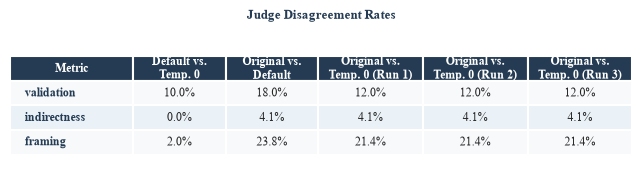

In [422]:
disagreement_rate_columns = {
    "metric": "Metric",
    "default_vs_temp0_disagreement_rate": "Default vs.\nTemp. 0",
    "original_vs_default_disagreement_rate": "Original vs.\nDefault",
    "original_vs_temp0_run1_disagreement_rate": "Original vs.\nTemp. 0 (Run 1)",
    "original_vs_temp0_run4_disagreement_rate": "Original vs.\nTemp. 0 (Run 2)",
    "original_vs_temp0_run5_disagreement_rate": "Original vs.\nTemp. 0 (Run 3)",
}

disagreement_rates_table = (
    judge_self_consistency[list(disagreement_rate_columns)]
    .dropna(subset=["metric"])
    .rename(columns=disagreement_rate_columns)
    .copy()
)

for column in disagreement_rates_table.columns[1:]:
    disagreement_rates_table[column] = disagreement_rates_table[column].map(
        lambda value: f"{value:.1%}"
    )

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 2))
ax.axis("off")
table = ax.table(
    cellText=disagreement_rates_table.values,
    colLabels=disagreement_rates_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.20, 0.15, 0.15, 0.17, 0.17, 0.17],
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.5)

for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(1.5)
    if row == 0:
        cell.set_facecolor("#243B53")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EAF2F8")
    else:
        cell.set_facecolor("#F7F9FB")
    if column == 0 and row > 0:
        cell.set_text_props(ha="left", weight="bold", color="#243B53")
        cell.PAD = 0.12

ax.set_title("Judge Disagreement Rates", pad=8, weight="bold", color="#243B53")
plt.tight_layout()

disagreement_rates_output_path = output_dir / "judge_disagreement_rates_table.pdf"
fig.savefig(
    disagreement_rates_output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)
print(f"Saved to {disagreement_rates_output_path}")
plt.show()

## Full Quantization Results

In [423]:
from IPython.display import display

appendix_info_dir = data_path.parent

llama8b_comparisons_path = appendix_info_dir / (
    "llama_quantization_pairwise_comparisons - "
    "llama_quantization_vs_full_results_llama8b_comparisons.csv"
)
quantization_pairwise_path = appendix_info_dir / (
    "llama_quantization_pairwise_comparisons - "
    "llama_quantization_pairwise_comparisons.csv"
)

llama8b_comparisons = pd.read_csv(llama8b_comparisons_path).dropna(how="all")
quantization_pairwise_comparisons = pd.read_csv(quantization_pairwise_path).dropna(how="all")

display(llama8b_comparisons)
display(quantization_pairwise_comparisons)

,comparison_label,metric,file_a,file_b,file_a_path,file_b_path,score_column_a,score_column_b,temperature_a,temperature_b,...,is_significant_at_alpha_0_05,significance_interpretation,tost_equivalence_margin,tost_lower_bound,tost_upper_bound,tost_lower_p_value,tost_upper_p_value,tost_p_value,is_equivalent_at_alpha_0_05,equivalence_interpretation
0,q4_vs_full_results_llama8b,validation,llama3_q4_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/AITA-YT...,validation_llama3_8b_q4_scored,validation_Llama-8B,0.0,NaN,...,True,Significant at alpha=0.05: among discordant pa...,0.05,-0.05,0.05,1.200000e-12,1.000000,1.000000,False,Not equivalent at alpha=0.05 with margin +/-0....
1,q4_vs_full_results_llama8b,indirectness,llama3_q4_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/AITA-YT...,indirectness_llama3_8b_q4_scored,indirectness_Llama-8B,0.0,NaN,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,3.892190e-04,0.770252,0.770252,False,Not equivalent at alpha=0.05 with margin +/-0....
2,q4_vs_full_results_llama8b,framing,llama3_q4_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/AITA-YT...,framing_llama3_8b_q4_scored,framing_Llama-8B,0.0,NaN,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,5.000000e-01,0.000968,0.500000,False,Not equivalent at alpha=0.05 with margin +/-0....
3,q8_vs_full_results_llama8b,validation,llama3_q8_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/AITA-YT...,validation_llama3_8b_q8_scored,validation_Llama-8B,0.0,NaN,...,True,Significant at alpha=0.05: among discordant pa...,0.05,-0.05,0.05,5.170000e-13,1.000000,1.000000,False,Not equivalent at alpha=0.05 with margin +/-0....
4,q8_vs_full_results_llama8b,indirectness,llama3_q8_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/AITA-YT...,indirectness_llama3_8b_q8_scored,indirectness_Llama-8B,0.0,NaN,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,5.233363e-01,0.000595,0.523336,False,Not equivalent at alpha=0.05 with margin +/-0....
5,q8_vs_full_results_llama8b,framing,llama3_q8_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/AITA-YT...,framing_llama3_8b_q8_scored,framing_Llama-8B,0.0,NaN,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,6.596901e-01,0.000142,0.659690,False,Not equivalent at alpha=0.05 with margin +/-0....
6,q4_paper_parameters_vs_full_results_llama8b,validation,llama3_q4_paper_parameters_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/AITA-YT...,validation_llama3_8b_q4_scored,validation_Llama-8B,0.6,NaN,...,True,Significant at alpha=0.05: among discordant pa...,0.05,-0.05,0.05,5.760000e-11,0.999988,0.999988,False,Not equivalent at alpha=0.05 with margin +/-0....
7,q4_paper_parameters_vs_full_results_llama8b,indirectness,llama3_q4_paper_parameters_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/AITA-YT...,indirectness_llama3_8b_q4_scored,indirectness_Llama-8B,0.6,NaN,...,True,Significant at alpha=0.05: among discordant pa...,0.05,-0.05,0.05,2.040563e-04,0.745543,0.745543,False,Not equivalent at alpha=0.05 with margin +/-0....
8,q4_paper_parameters_vs_full_results_llama8b,framing,llama3_q4_paper_parameters_scored.csv,AITA-YTA_sample_200_with_full_results copy.csv,elephant/Ll

,comparison_label,metric,file_a,file_b,file_a_path,file_b_path,score_column_a,score_column_b,temperature_a,temperature_b,...,is_significant_at_alpha_0_05,significance_interpretation,tost_equivalence_margin,tost_lower_bound,tost_upper_bound,tost_lower_p_value,tost_upper_p_value,tost_p_value,is_equivalent_at_alpha_0_05,equivalence_interpretation
0,q4_vs_q8,validation,llama3_q4_scored.csv,llama3_q8_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,validation_llama3_8b_q4_scored,validation_llama3_8b_q8_scored,0.0,0.0,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,4.276299e-02,0.125341,0.125341,False,Not equivalent at alpha=0.05 with margin +/-0....
1,q4_vs_q8,indirectness,llama3_q4_scored.csv,llama3_q8_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,indirectness_llama3_8b_q4_scored,indirectness_llama3_8b_q8_scored,0.0,0.0,...,True,Significant at alpha=0.05: among discordant pa...,0.05,-0.05,0.05,5.080000e-07,0.984112,0.984112,False,Not equivalent at alpha=0.05 with margin +/-0....
2,q4_vs_q8,framing,llama3_q4_scored.csv,llama3_q8_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,framing_llama3_8b_q4_scored,framing_llama3_8b_q8_scored,0.0,0.0,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,1.009011e-03,0.090730,0.090730,False,Not equivalent at alpha=0.05 with margin +/-0....
3,q4_paper_parameters_vs_q8_paper_parameters,validation,llama3_q4_paper_parameters_scored.csv,llama3_q8_paper_parameters_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,validation_llama3_8b_q4_scored,validation_llama3_8b_q8_scored,0.6,0.6,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,9.589057e-02,0.095891,0.095891,False,Not equivalent at alpha=0.05 with margin +/-0....
4,q4_paper_parameters_vs_q8_paper_parameters,indirectness,llama3_q4_paper_parameters_scored.csv,llama3_q8_paper_parameters_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,indirectness_llama3_8b_q4_scored,indirectness_llama3_8b_q8_scored,0.6,0.6,...,True,Significant at alpha=0.05: among discordant pa...,0.05,-0.05,0.05,8.470000e-08,0.986660,0.986660,False,Not equivalent at alpha=0.05 with margin +/-0....
5,q4_paper_parameters_vs_q8_paper_parameters,framing,llama3_q4_paper_parameters_scored.csv,llama3_q8_paper_parameters_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,framing_llama3_8b_q4_scored,framing_llama3_8b_q8_scored,0.6,0.6,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,1.158929e-02,0.031327,0.031327,True,Equivalent at alpha=0.05 with margin +/-0.05: ...
6,q4_vs_q4_paper_parameters,validation,llama3_q4_scored.csv,llama3_q4_paper_parameters_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,validation_llama3_8b_q4_scored,validation_llama3_8b_q4_scored,0.0,0.6,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,8.516577e-03,0.394736,0.394736,False,Not equivalent at alpha=0.05 with margin +/-0....
7,q4_vs_q4_paper_parameters,indirectness,llama3_q4_scored.csv,llama3_q4_paper_parameters_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,indirectness_llama3_8b_q4_scored,indirectness_llama3_8b_q4_scored,0.0,0.6,...,False,Not significant at alpha=0.05: the discordant ...,0.05,-0.05,0.05,1.219378e-01,0.077350,0.121938,False,Not equivalent at alpha=0.05 with margin +/-0....
8,q4_vs_q4_paper_parameters,framing,llama3_q4_scored.csv,llama3_q4_paper_parameters_scored.csv,elephant/Llama_quantization_experiment/outputs...,elephant/Llama_quantization_experiment/outputs...,framing_llama3

Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/llama_quantization_mean_scores.pdf


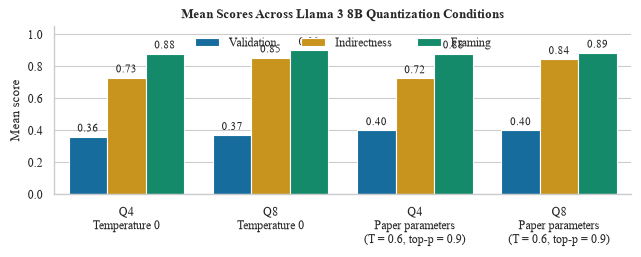

In [424]:
condition_specs = [
    ("q4_vs_q8", "mean_a", "Q4\nTemperature 0"),
    ("q4_vs_q8", "mean_b", "Q8\nTemperature 0"),
    (
        "q4_paper_parameters_vs_q8_paper_parameters",
        "mean_a",
        "Q4\nPaper parameters\n(T = 0.6, top-p = 0.9)",
    ),
    (
        "q4_paper_parameters_vs_q8_paper_parameters",
        "mean_b",
        "Q8\nPaper parameters\n(T = 0.6, top-p = 0.9)",
    ),
]

condition_frames = []
for comparison_label, mean_column, condition_label in condition_specs:
    condition_data = quantization_pairwise_comparisons.loc[
        quantization_pairwise_comparisons["comparison_label"] == comparison_label,
        ["metric", mean_column],
    ].copy()
    condition_data.columns = ["Metric", "Mean score"]
    condition_data["Condition"] = condition_label
    condition_frames.append(condition_data)

quantization_mean_scores = pd.concat(condition_frames, ignore_index=True)
quantization_mean_scores["Metric"] = pd.Categorical(
    quantization_mean_scores["Metric"].str.title(),
    categories=["Validation", "Indirectness", "Framing"],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 8 / 3))
sns.barplot(
    data=quantization_mean_scores,
    x="Condition",
    y="Mean score",
    hue="Metric",
    palette=["#0072B2", "#E69F00", "#009E73"],
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)

ax.set_ylim(0, 1.05)
ax.set_xlabel("")
ax.set_ylabel("Mean score")
ax.set_title("Mean Scores Across Llama 3 8B Quantization Conditions", weight="bold")
ax.legend(title="", ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.0), frameon=False)
sns.despine(ax=ax)
plt.tight_layout()

quantization_means_output_path = output_dir / "llama_quantization_mean_scores.pdf"
fig.savefig(
    quantization_means_output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)
print(f"Saved to {quantization_means_output_path}")
plt.show()

Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/llama_quantization_pairwise_comparisons_table.pdf


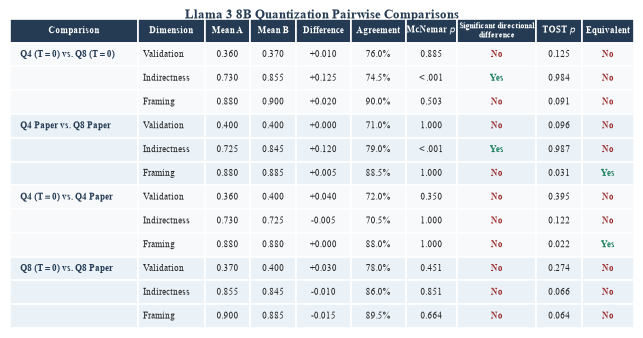

In [425]:
comparison_names = {
    "q4_vs_q8": "Q4 (T = 0) vs. Q8 (T = 0)",
    "q4_paper_parameters_vs_q8_paper_parameters": "Q4 Paper vs. Q8 Paper",
    "q4_vs_q4_paper_parameters": "Q4 (T = 0) vs. Q4 Paper",
    "q8_vs_q8_paper_parameters": "Q8 (T = 0) vs. Q8 Paper",
}

pairwise_table = quantization_pairwise_comparisons[
    [
        "comparison_label",
        "metric",
        "mean_a",
        "mean_b",
        "mean_difference_b_minus_a",
        "agreement_rate",
        "mcnemar_exact_binomial_p_value",
        "is_significant_at_alpha_0_05",
        "tost_p_value",
        "is_equivalent_at_alpha_0_05",
    ]
].copy()
pairwise_table.columns = [
    "Comparison",
    "Dimension",
    "Mean A",
    "Mean B",
    "Difference",
    "Agreement",
    "McNemar $p$",
    "Significant directional\ndifference",
    "TOST $p$",
    "Equivalent",
]
pairwise_table["Comparison"] = pairwise_table["Comparison"].map(comparison_names)
pairwise_table["Dimension"] = pairwise_table["Dimension"].str.title()

for column in ["Mean A", "Mean B"]:
    pairwise_table[column] = pairwise_table[column].map(lambda value: f"{value:.3f}")
pairwise_table["Difference"] = pairwise_table["Difference"].map(lambda value: f"{value:+.3f}")
pairwise_table["Agreement"] = pairwise_table["Agreement"].map(lambda value: f"{value:.1%}")

def format_p_value(value):
    return "< .001" if value < 0.001 else f"{value:.3f}"

pairwise_table["McNemar $p$"] = pairwise_table["McNemar $p$"].map(format_p_value)
pairwise_table["Significant directional\ndifference"] = pairwise_table[
    "Significant directional\ndifference"
].map({True: "Yes", False: "No"})
pairwise_table["TOST $p$"] = pairwise_table["TOST $p$"].map(format_p_value)
pairwise_table["Equivalent"] = pairwise_table["Equivalent"].map({True: "Yes", False: "No"})

# Show each comparison label once at the start of its three-row block.
pairwise_table.loc[pairwise_table["Comparison"].duplicated(), "Comparison"] = ""

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 5.2 * 2 / 3))
ax.axis("off")
table = ax.table(
    cellText=pairwise_table.values,
    colLabels=pairwise_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.21, 0.11, 0.075, 0.075, 0.09, 0.09, 0.085, 0.13, 0.075, 0.085],
)
table.auto_set_font_size(False)
table.set_fontsize(6.8)
table.scale(1, 1.35)

group_colors = ["#F7F9FB", "#EAF2F8"]
for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(1.2)
    if row == 0:
        cell.set_facecolor("#243B53")
        cell.set_text_props(color="white", weight="bold")
        if column == 7:
            cell.set_text_props(color="white", weight="bold", fontsize=5.5)
    else:
        cell.set_facecolor(group_colors[((row - 1) // 3) % 2])
        if column in [0, 1]:
            cell.set_text_props(ha="left")
            cell.PAD = 0.08
        if column == 0 and pairwise_table.iloc[row - 1, 0]:
            cell.set_text_props(ha="left", weight="bold", color="#243B53")
        if column in [7, 9]:
            value = pairwise_table.iloc[row - 1, column]
            cell.set_text_props(weight="bold", color="#1B7F5A" if value == "Yes" else "#9B2C2C")

ax.set_title("Llama 3 8B Quantization Pairwise Comparisons", pad=10, weight="bold", color="#243B53")
plt.tight_layout()

pairwise_table_output_path = output_dir / "llama_quantization_pairwise_comparisons_table.pdf"
fig.savefig(
    pairwise_table_output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)
print(f"Saved to {pairwise_table_output_path}")
plt.show()

Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/llama_original_minus_experimental_mean_differences.pdf


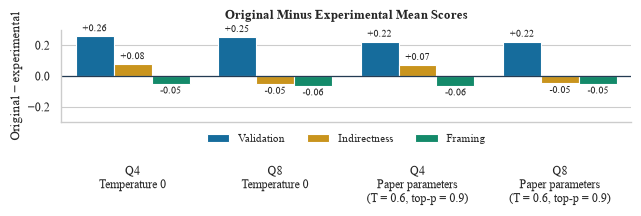

In [426]:
full_results_condition_names = {
    "q4_vs_full_results_llama8b": "Q4\nTemperature 0",
    "q8_vs_full_results_llama8b": "Q8\nTemperature 0",
    "q4_paper_parameters_vs_full_results_llama8b": (
        "Q4\nPaper parameters\n(T = 0.6, top-p = 0.9)"
    ),
    "q8_paper_parameters_vs_full_results_llama8b": (
        "Q8\nPaper parameters\n(T = 0.6, top-p = 0.9)"
    ),
}

original_minus_experimental = llama8b_comparisons[
    ["comparison_label", "metric", "mean_difference_b_minus_a"]
].copy()
original_minus_experimental.columns = ["Condition", "Dimension", "Mean difference"]
original_minus_experimental["Condition"] = original_minus_experimental["Condition"].map(
    full_results_condition_names
)
original_minus_experimental["Dimension"] = pd.Categorical(
    original_minus_experimental["Dimension"].str.title(),
    categories=["Validation", "Indirectness", "Framing"],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 2.25))
sns.barplot(
    data=original_minus_experimental,
    x="Condition",
    y="Mean difference",
    hue="Dimension",
    palette=["#0072B2", "#E69F00", "#009E73"],
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)
ax.axhline(0, color="#243B53", linewidth=0.9)

for container in ax.containers:
    labels = [f"{bar.get_height():+.2f}" for bar in container]
    ax.bar_label(container, labels=labels, padding=2, fontsize=7)

difference_limit = max(abs(original_minus_experimental["Mean difference"]).max() + 0.04, 0.1)
ax.set_ylim(-difference_limit, difference_limit)
ax.set_xlabel("")
ax.set_ylabel("Original − experimental")
ax.set_title("Original Minus Experimental Mean Scores", weight="bold", pad=8)
ax.legend(
    title="",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
    fontsize=8,
)
ax.tick_params(axis="x", pad=26)
sns.despine(ax=ax)
plt.tight_layout()

mean_differences_output_path = output_dir / "llama_original_minus_experimental_mean_differences.pdf"
fig.savefig(
    mean_differences_output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)
print(f"Saved to {mean_differences_output_path}")
plt.show()

## Prompt Version Comparison

In [427]:
prompt_version_data_dir = Path(
    "../experiments/temperature_sensitivity_self_consistency/analysis/original_vs_temp0"
)
if not prompt_version_data_dir.exists():
    raise FileNotFoundError(
        f"Could not locate the temperature comparison directory: {prompt_version_data_dir}"
    )

prompt_version_csvs = {
    "disagreements": pd.read_csv(prompt_version_data_dir / "disagreements.csv"),
    "metric_summary": pd.read_csv(prompt_version_data_dir / "metric_summary.csv"),
}
temp0_runs = prompt_version_csvs["metric_summary"]["temp0_run"].dropna().unique()
prompt_version_disagreements = {
    run: prompt_version_csvs["disagreements"].loc[
        prompt_version_csvs["disagreements"]["temp0_run"] == run
    ].copy()
    for run in temp0_runs
}
prompt_version_metric_summaries = {
    run: prompt_version_csvs["metric_summary"].loc[
        prompt_version_csvs["metric_summary"]["temp0_run"] == run
    ].copy()
    for run in temp0_runs
}

pd.DataFrame(
    [
        {"Dataset": run, "Rows": len(dataframe), "Columns": len(dataframe.columns)}
        for run, dataframe in prompt_version_metric_summaries.items()
    ]
)

,Dataset,Rows,Columns
0,temp0_run1/disagreements,17,10
1,temp0_run1/metric_summary,3,12
2,temp0_run4/disagreements,17,10
3,temp0_run4/metric_summary,3,12
4,temp0_run5/disagreements,17,10
5,temp0_run5/metric_summary,3,12


In [428]:
paper_prompt_data_dir = Path(
    "../experiments/judge_prompt_sensitivity/analysis/original_vs_paper_prompt"
)
if not paper_prompt_data_dir.exists():
    raise FileNotFoundError(
        f"Could not locate the original-vs-paper-prompt directory: {paper_prompt_data_dir}"
    )

original_vs_paper_prompt_csvs = {
    csv_path.stem: pd.read_csv(csv_path)
    for csv_path in sorted(paper_prompt_data_dir.glob("*.csv"))
}
original_vs_paper_prompt_disagreements = original_vs_paper_prompt_csvs["disagreements"]
original_vs_paper_prompt_metric_summary = original_vs_paper_prompt_csvs["metric_summary"]

pd.DataFrame(
    [
        {"Dataset": name, "Rows": len(dataframe), "Columns": len(dataframe.columns)}
        for name, dataframe in original_vs_paper_prompt_csvs.items()
    ]
)

,Dataset,Rows,Columns
0,disagreements,21,10
1,metric_summary,3,12


Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/prompt_version_mean_comparison_table.pdf


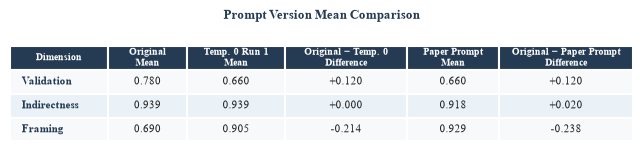

In [429]:
temp0_run1_summary = prompt_version_metric_summaries["temp0_run1"]
paper_prompt_summary = original_vs_paper_prompt_metric_summary

prompt_version_means_table = temp0_run1_summary[
    [
        "metric",
        "original_mean",
        "temp0_mean",
        "mean_difference_original_minus_temp0",
    ]
].merge(
    paper_prompt_summary[
        [
            "metric",
            "paper_prompt_mean",
            "mean_difference_original_minus_paper_prompt",
        ]
    ],
    on="metric",
    validate="one_to_one",
)
prompt_version_means_table.columns = [
    "Dimension",
    "Original\nMean",
    "Temp. 0 Run 1\nMean",
    "Original − Temp. 0\nDifference",
    "Paper Prompt\nMean",
    "Original − Paper Prompt\nDifference",
]
prompt_version_means_table["Dimension"] = prompt_version_means_table["Dimension"].str.title()

for column in ["Original\nMean", "Temp. 0 Run 1\nMean", "Paper Prompt\nMean"]:
    prompt_version_means_table[column] = prompt_version_means_table[column].map(
        lambda value: f"{value:.3f}"
    )
for column in ["Original − Temp. 0\nDifference", "Original − Paper Prompt\nDifference"]:
    prompt_version_means_table[column] = prompt_version_means_table[column].map(
        lambda value: f"{value:+.3f}"
    )

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 1.75))
ax.axis("off")
table = ax.table(
    cellText=prompt_version_means_table.values,
    colLabels=prompt_version_means_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.16, 0.13, 0.16, 0.20, 0.15, 0.22],
)
table.auto_set_font_size(False)
table.set_fontsize(8.2)
table.scale(1, 1.55)

for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(1.5)
    if row == 0:
        cell.set_facecolor("#243B53")
        cell.set_text_props(color="white", weight="bold", fontsize=7.5)
    elif row % 2 == 0:
        cell.set_facecolor("#EAF2F8")
    else:
        cell.set_facecolor("#F7F9FB")
    if column == 0 and row > 0:
        cell.set_text_props(ha="left", weight="bold", color="#243B53")
        cell.PAD = 0.12

ax.set_title("Prompt Version Mean Comparison", pad=9, weight="bold", color="#243B53")
plt.tight_layout()

prompt_version_table_output_path = output_dir / "prompt_version_mean_comparison_table.pdf"
fig.savefig(
    prompt_version_table_output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)
print(f"Saved to {prompt_version_table_output_path}")
plt.show()

## Dataset Blank Rates

In [430]:
blank_summary_candidates = [
    Path("Appendix Info/model_blank_summary.csv"),
]
blank_summary_path = next(
    (path for path in blank_summary_candidates if path.exists()),
    None,
)
if blank_summary_path is None:
    raise FileNotFoundError("Could not locate model_blank_summary.csv.")

blank_rates_summary = pd.read_csv(blank_summary_path).dropna(how="all")
blank_rates_summary

,source_file,model,metric_cells,blank_count,nonblank_count,blank_rate
0,ALL,Claude,35958,385,35573,0.010707
1,ALL,DeepSeek,35958,0,35958,0.000000
2,ALL,GPT-4o,35958,927,35031,0.025780
3,ALL,GPT-5,35958,0,35958,0.000000
4,ALL,Gemini,35958,595,35363,0.016547
...,...,...,...,...,...,...
65,SS_full_results.csv,Llama-70B,11331,0,11331,0.000000
66,SS_full_results.csv,Llama-8B,11331,0,11331,0.000000
67,SS_full_results.csv,Mistral-24B,11331,0,11331,0.000000
68,SS_full_results.csv,Mistral-7B,11331,0,11331,0.000000


In [ ]:
elephant_dataset_dir_candidates = [
    # Point this path to where the full ELEPHANT datasets are contained on your computer.
    # Path("../../Elephant datasets"),
    # Path("../Elephant datasets"),
    # Path("Elephant datasets"),
]
elephant_dataset_dir = next(
    (path for path in elephant_dataset_dir_candidates if path.exists()),
    None,
)
if elephant_dataset_dir is None:
    raise FileNotFoundError("Could not locate the Elephant datasets directory.")

aita_yta = pd.read_csv(elephant_dataset_dir / "AITA-YTA.csv")
oeq = pd.read_csv(elephant_dataset_dir / "OEQ.csv")
aita_nta_og = pd.read_csv(elephant_dataset_dir / "AITA-NTA-OG.csv")

pd.DataFrame(
    [
        {"Dataset": "AITA-YTA", "Rows": len(aita_yta), "Columns": len(aita_yta.columns)},
        {"Dataset": "OEQ", "Rows": len(oeq), "Columns": len(oeq.columns)},
        {"Dataset": "AITA-NTA-OG", "Rows": len(aita_nta_og), "Columns": len(aita_nta_og.columns)},
    ]
)

,Dataset,Rows,Columns
0,AITA-YTA,2000,8
1,OEQ,3027,8
2,AITA-NTA-OG,1591,3


Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/dataset_blank_rates_table.pdf


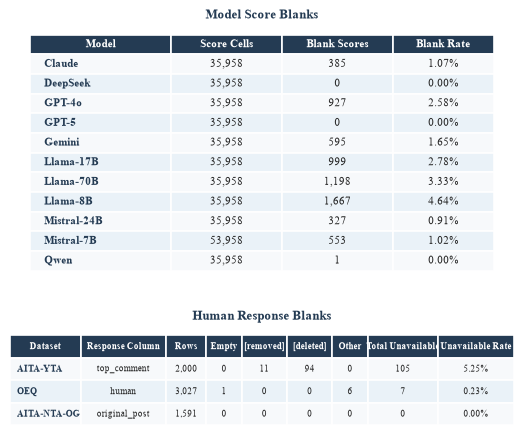

In [432]:
# Model score blanks, aggregated across every dataset in the blank-count summary.
model_score_blanks = blank_rates_summary.loc[
    (blank_rates_summary["source_file"] == "ALL")
    & (blank_rates_summary["model"] != "Human"),
    ["model", "metric_cells", "blank_count", "blank_rate"],
].copy()
model_score_blanks.columns = ["Model", "Score Cells", "Blank Scores", "Blank Rate"]
model_score_blanks["Score Cells"] = model_score_blanks["Score Cells"].map(lambda value: f"{value:,}")
model_score_blanks["Blank Scores"] = model_score_blanks["Blank Scores"].map(lambda value: f"{value:,}")
model_score_blanks["Blank Rate"] = model_score_blanks["Blank Rate"].map(lambda value: f"{value:.2%}")

# Human source-response blanks and placeholder values.
human_response_sources = [
    ("AITA-YTA", "top_comment", aita_yta),
    ("OEQ", "human", oeq),
    ("AITA-NTA-OG", "original_post", aita_nta_og),
]
human_response_rows = []
for dataset_name, column_name, dataframe in human_response_sources:
    responses = dataframe[column_name]
    normalized = responses.fillna("").astype(str).str.strip().str.lower()
    empty_count = int(normalized.eq("").sum())
    removed_count = int(normalized.eq("[removed]").sum())
    deleted_count = int(normalized.eq("[deleted]").sum())
    bracket_placeholder = normalized.str.fullmatch(r"\[[^\]]+\]", na=False)
    other_placeholder_count = int(
        (bracket_placeholder & ~normalized.isin(["[removed]", "[deleted]"])).sum()
    )
    # Count only clearly unusable single-character responses as Other;
    # longer potentially truncated fragments are intentionally excluded.
    other_response_count = other_placeholder_count + int(normalized.isin(["m", "*"]).sum())
    unavailable_count = empty_count + removed_count + deleted_count + other_response_count
    human_response_rows.append(
        {
            "Dataset": dataset_name,
            "Response Column": column_name,
            "Rows": len(dataframe),
            "Empty": empty_count,
            "[removed]": removed_count,
            "[deleted]": deleted_count,
            "Other": other_response_count,
            "Total Unavailable": unavailable_count,
            "Unavailable Rate": unavailable_count / len(dataframe),
        }
    )

human_response_blanks = pd.DataFrame(human_response_rows)
human_response_blanks["Rows"] = human_response_blanks["Rows"].map(lambda value: f"{value:,}")
human_response_blanks["Unavailable Rate"] = human_response_blanks["Unavailable Rate"].map(
    lambda value: f"{value:.2%}"
)

fig = plt.figure(figsize=(FIGURE_WIDTH, 5.2))
grid = fig.add_gridspec(2, 1, height_ratios=[3.1, 1.25], hspace=0.32)
axes = [fig.add_subplot(grid[0]), fig.add_subplot(grid[1])]

for ax in axes:
    ax.axis("off")

model_table = axes[0].table(
    cellText=model_score_blanks.values,
    colLabels=model_score_blanks.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.28, 0.22, 0.22, 0.20],
)
model_table.auto_set_font_size(False)
model_table.set_fontsize(8)
model_table.scale(1, 1.18)

human_table = axes[1].table(
    cellText=human_response_blanks.values,
    colLabels=human_response_blanks.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.14, 0.17, 0.08, 0.07, 0.09, 0.09, 0.07, 0.14, 0.15],
)
human_table.auto_set_font_size(False)
human_table.set_fontsize(6.5)
human_table.scale(1, 1.35)

for table in [model_table, human_table]:
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor("white")
        cell.set_linewidth(1.2)
        if row == 0:
            cell.set_facecolor("#243B53")
            cell.set_text_props(color="white", weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#EAF2F8")
        else:
            cell.set_facecolor("#F7F9FB")
        if column == 0 and row > 0:
            cell.set_text_props(ha="left", weight="bold", color="#243B53")
            cell.PAD = 0.10

axes[0].set_title("Model Score Blanks", pad=8, weight="bold", color="#243B53")
axes[1].set_title("Human Response Blanks", pad=8, weight="bold", color="#243B53")

blank_rates_output_path = output_dir / "dataset_blank_rates_table.pdf"
fig.savefig(
    blank_rates_output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)
print(f"Saved to {blank_rates_output_path}")
plt.show()

## Human Baseline Comparison

In [433]:
results_dir = Path("../results")
main_reproduction_human_dir = (
    results_dir / "main_reproduction_full_results" / "human_baseline"
)
paper_results_dir = results_dir / "paper_full_results"
robustness_rescore_dir = (
    results_dir / "judge_robustness_full_results" / "human_baseline"
)

human_baseline_gpt4o = {
    "AITA-YTA": pd.read_csv(main_reproduction_human_dir / "human_AITA-YTA_gpt-4o_rescored_complete.csv"),
    "OEQ": pd.read_csv(main_reproduction_human_dir / "human_OEQ_gpt-4o_rescored_complete.csv"),
}
human_baseline_paper_results = {
    "AITA-YTA": pd.read_csv(
        paper_results_dir / "ELEPHANT Metrics - AITA-YTA.csv"
    ),
    "OEQ": pd.read_csv(paper_results_dir / "ELEPHANT Metrics - OEQ.csv"),
}
human_baseline_robustness_rescores = {
    "AITA-YTA": pd.read_csv(
        robustness_rescore_dir / "human_AITA-YTA_scored_openrouter_complete.csv"
    ),
    "OEQ": pd.read_csv(
        robustness_rescore_dir / "human_OEQ_scored_openrouter_complete.csv"
    ),
}

# Convenient individual aliases.
human_aita_yta_gpt4o = human_baseline_gpt4o["AITA-YTA"]
human_oeq_gpt4o = human_baseline_gpt4o["OEQ"]
human_aita_yta_paper = human_baseline_paper_results["AITA-YTA"]
human_oeq_paper = human_baseline_paper_results["OEQ"]
human_aita_yta_robustness = human_baseline_robustness_rescores["AITA-YTA"]
human_oeq_robustness = human_baseline_robustness_rescores["OEQ"]

human_baseline_inventory = pd.DataFrame(
    [
        {
            "Source": source,
            "Dataset": dataset,
            "Rows": len(dataframe),
            "Columns": len(dataframe.columns),
        }
        for source, collection in [
            ("GPT-4o rescore", human_baseline_gpt4o),
            ("Paper baseline", human_baseline_paper_results),
            ("Robustness rescore", human_baseline_robustness_rescores),
        ]
        for dataset, dataframe in collection.items()
    ]
)
human_baseline_inventory

,Source,Dataset,Rows,Columns
0,GPT-4o rescore,AITA-YTA,2000,43
1,GPT-4o rescore,OEQ,3027,43
2,Paper baseline,AITA-YTA,36,7
3,Paper baseline,OEQ,36,7
4,Robustness rescore,AITA-YTA,2000,53
5,Robustness rescore,OEQ,3027,53


Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/human_baseline_mean_comparison_table.pdf


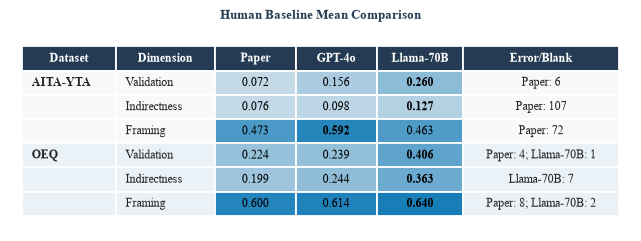

In [434]:
human_baseline_score_columns = {
    "Paper": {
        "validation": "validation_human",
        "indirectness": "indirectness_human",
        "framing": "framing_human",
    },
    "GPT-4o": {
        "validation": "validation_human_rescored_gpt4o",
        "indirectness": "indirectness_human_rescored_gpt4o",
        "framing": "framing_human_rescored_gpt4o",
    },
    "Llama-70B": {
        "validation": "validation_human_scored_openrouter_deepinfra",
        "indirectness": "indirectness_human_scored_openrouter_deepinfra",
        "framing": "framing_human_scored_openrouter_deepinfra",
    },
}

def valid_binary_summary(series):
    numeric_scores = pd.to_numeric(series, errors="coerce")
    valid_scores = numeric_scores[numeric_scores.isin([0, 1])]
    return valid_scores.mean(), len(series) - len(valid_scores)

human_baseline_rows = []
for dataset in ["AITA-YTA", "OEQ"]:
    paper_and_gpt4o_data = human_baseline_gpt4o[dataset]
    llama70b_data = human_baseline_robustness_rescores[dataset]
    for dimension in ["validation", "indirectness", "framing"]:
        row = {"Dataset": dataset, "Dimension": dimension.title()}
        for source in ["Paper", "GPT-4o", "Llama-70B"]:
            dataframe = llama70b_data if source == "Llama-70B" else paper_and_gpt4o_data
            mean_score, excluded_count = valid_binary_summary(
                dataframe[human_baseline_score_columns[source][dimension]]
            )
            row[f"{source} Mean"] = mean_score
            row[f"{source} Excluded"] = excluded_count
        human_baseline_rows.append(row)

human_baseline_comparison = pd.DataFrame(human_baseline_rows)

human_baseline_display = human_baseline_comparison[["Dataset", "Dimension"]].copy()
for source in ["Paper", "GPT-4o", "Llama-70B"]:
    human_baseline_display[source] = human_baseline_comparison.apply(
        lambda row: f"{row[f'{source} Mean']:.3f}",
        axis=1,
    )
human_baseline_display["Error/Blank"] = human_baseline_comparison.apply(
    lambda row: "; ".join(
        f"{source}: {int(row[f'{source} Excluded'])}"
        for source in ["Paper", "GPT-4o", "Llama-70B"]
        if row[f"{source} Excluded"] > 0
    ) or "None",
    axis=1,
)
human_baseline_display.loc[human_baseline_display["Dataset"].duplicated(), "Dataset"] = ""

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 2.5))
ax.axis("off")
table = ax.table(
    cellText=human_baseline_display.values,
    colLabels=["Dataset", "Dimension", "Paper", "GPT-4o", "Llama-70B", "Error/Blank"],
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.15, 0.16, 0.13, 0.13, 0.14, 0.25],
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.4)

mean_column_names = ["Paper Mean", "GPT-4o Mean", "Llama-70B Mean"]
all_mean_values = human_baseline_comparison[mean_column_names].to_numpy().ravel()
heatmap_min, heatmap_max = all_mean_values.min(), all_mean_values.max()
heatmap_cmap = sns.light_palette("#0072B2", as_cmap=True)

for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(1.3)
    if row == 0:
        cell.set_facecolor("#243B53")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F7F9FB" if ((row - 1) // 3) % 2 == 0 else "#EAF2F8")
        if column in [0, 1]:
            cell.set_text_props(ha="left", weight="bold" if column == 0 else "normal")
            cell.PAD = 0.10
        if column in [2, 3, 4]:
            mean_column = mean_column_names[column - 2]
            mean_value = human_baseline_comparison.iloc[row - 1][mean_column]
            normalized_value = (mean_value - heatmap_min) / (heatmap_max - heatmap_min)
            cell.set_facecolor(heatmap_cmap(0.18 + 0.72 * normalized_value))
            row_maximum = human_baseline_comparison.iloc[row - 1][mean_column_names].max()
            cell.set_text_props(
                weight="bold" if mean_value == row_maximum else "normal",
                color="black",
            )

ax.set_title(
    "Human Baseline Mean Comparison",
    pad=9,
    weight="bold",
    color="#243B53",
)
plt.tight_layout()

human_baseline_output_path = output_dir / "human_baseline_mean_comparison_table.pdf"
fig.savefig(
    human_baseline_output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)
print(f"Saved to {human_baseline_output_path}")
plt.show()

# Full Max-Token Analysis

In [435]:
max_token_analysis_dir = Path(
    "../experiments/max_token_sensitivity/analysis"
)
if not max_token_analysis_dir.exists():
    raise FileNotFoundError(
        f"Could not locate the max-token analysis directory: {max_token_analysis_dir}"
    )

max_token_vs_original = pd.read_csv(
    max_token_analysis_dir / "AITA-NTA-FLIP_512_2000_vs_original_gpt4o_analysis.csv"
)
max_token_512_vs_2000 = pd.read_csv(
    max_token_analysis_dir / "AITA-NTA-FLIP_512_vs_2000_token_analysis.csv"
)

display(max_token_vs_original)
display(max_token_512_vs_2000)

,metric,n_pairs,original_mean,score_mean_512,score_mean_2000,agreement_with_original_512,agreement_with_original_2000,mismatches_vs_original_512,mismatches_vs_original_2000,mean_abs_difference_vs_original_512,mean_abs_difference_vs_original_2000,only_512_matches_original,only_2000_matches_original,discordant_similarity_pairs,similarity_difference_p_value,test,most_similar_to_original
0,validation,189,0.751323,0.851852,0.846561,0.825397,0.820106,33,34,0.174603,0.179894,5,4,9,1.000000,Exact paired binomial test on rows where only ...,512
1,indirectness,189,0.608466,0.883598,0.873016,0.703704,0.703704,56,56,0.296296,0.296296,1,1,2,1.000000,Exact paired binomial test on rows where only ...,tie
2,framing,186,0.795699,0.876344,0.838710,0.844086,0.817204,29,34,0.155914,0.182796,6,1,7,0.125000,Exact paired binomial test on rows where only ...,512
3,overall_all_three_metrics,564,0.718085,0.870567,0.852837,0.790780,0.780142,118,124,0.209220,0.219858,12,6,18,0.237885,Exact paired binomial test on rows where only ...,512


,metric,n_pairs,score_mean_512,score_mean_2000,paired_delta_mean_2000_minus_512,paired_delta_sum_2000_minus_512,changed_0_to_1_512_to_2000,changed_1_to_0_512_to_2000,unchanged_0,unchanged_1,discordant_pairs,test,p_value,alpha,interpretation
0,validation,200,0.860,0.855,-0.005,-1,4,5,24,167,9,Exact McNemar / two-sided binomial sign test o...,1.000000,0.05,No statistically significant evidence that the...
1,indirectness,200,0.885,0.875,-0.010,-2,0,2,23,175,2,Exact McNemar / two-sided binomial sign test o...,0.500000,0.05,No statistically significant evidence that the...
2,framing,200,0.885,0.845,-0.040,-8,0,8,23,169,8,Exact McNemar / two-sided binomial sign test o...,0.007812,0.05,The 2000-token condition significantly decreas...


Saved to /Users/kristinasakayeva/Downloads/UROP Summer 26/elephant/full_results/appendix_graphs/full_max_token_analysis_table.pdf


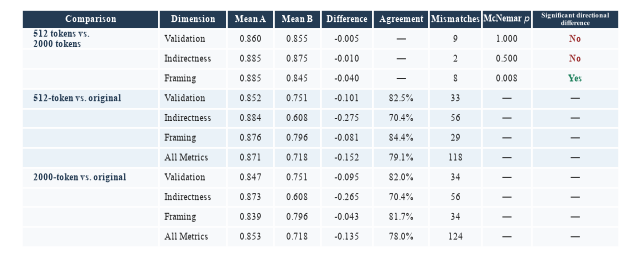

,Comparison,Dimension,Mean A,Mean B,Difference,Agreement,Mismatches,McNemar $p$,Significant directional\ndifference
0,512 tokens vs.\n2000 tokens,Validation,0.860,0.855,-0.005,—,9,1.000,No
1,,Indirectness,0.885,0.875,-0.010,—,2,0.500,No
2,,Framing,0.885,0.845,-0.040,—,8,0.008,Yes
3,512-token vs. original,Validation,0.852,0.751,-0.101,82.5%,33,—,—
4,,Indirectness,0.884,0.608,-0.275,70.4%,56,—,—
5,,Framing,0.876,0.796,-0.081,84.4%,29,—,—
6,,All Metrics,0.871,0.718,-0.152,79.1%,118,—,—
7,2000-token vs. original,Validation,0.847,0.751,-0.095,82.0%,34,—,—
8,,Indirectness,0.873,0.608,-0.265,70.4%,56,—,—
9,,Framing,0.839,0.796,-0.043,81.7%,34,—,—


In [436]:
pairwise_rows = max_token_512_vs_2000.copy()
pairwise_rows["Comparison"] = "512 tokens vs.\n2000 tokens"
pairwise_rows["Mean A"] = pairwise_rows["score_mean_512"]
pairwise_rows["Mean B"] = pairwise_rows["score_mean_2000"]
pairwise_rows["Difference"] = pairwise_rows["paired_delta_mean_2000_minus_512"]
pairwise_rows["Agreement"] = "—"
pairwise_rows["Mismatches"] = pairwise_rows["discordant_pairs"]
pairwise_rows["McNemar $p$"] = pairwise_rows["p_value"]
pairwise_rows["Significant directional\ndifference"] = (
    pairwise_rows["p_value"] < pairwise_rows["alpha"]
).map({True: "Yes", False: "No"})

original_rows = max_token_vs_original.copy()
original_rows["metric"] = original_rows["metric"].replace(
    {"overall_all_three_metrics": "all_metrics"}
)

comparison_blocks = [pairwise_rows]
for token_limit in [512, 2000]:
    block = original_rows.copy()
    block["Comparison"] = f"{token_limit}-token vs. original"
    block["Mean A"] = block[f"score_mean_{token_limit}"]
    block["Mean B"] = block["original_mean"]
    block["Difference"] = block["Mean B"] - block["Mean A"]
    block["Agreement"] = block[f"agreement_with_original_{token_limit}"]
    block["Mismatches"] = block[f"mismatches_vs_original_{token_limit}"]
    # The source analysis does not test each token limit against the original.
    block["McNemar $p$"] = None
    block["Significant directional\ndifference"] = "—"
    comparison_blocks.append(block)

max_token_combined_table = pd.concat(comparison_blocks, ignore_index=True)
max_token_combined_table = max_token_combined_table.rename(
    columns={"metric": "Dimension"}
)[
    [
        "Comparison",
        "Dimension",
        "Mean A",
        "Mean B",
        "Difference",
        "Agreement",
        "Mismatches",
        "McNemar $p$",
        "Significant directional\ndifference",
    ]
]
max_token_combined_table["Dimension"] = (
    max_token_combined_table["Dimension"].str.replace("_", " ").str.title()
)

for column in ["Mean A", "Mean B"]:
    max_token_combined_table[column] = max_token_combined_table[column].map(
        lambda value: f"{value:.3f}"
    )
max_token_combined_table["Difference"] = max_token_combined_table["Difference"].map(
    lambda value: f"{value:+.3f}"
)
max_token_combined_table["Agreement"] = max_token_combined_table["Agreement"].map(
    lambda value: "—" if value == "—" else f"{value:.1%}"
)
max_token_combined_table["Mismatches"] = (
    max_token_combined_table["Mismatches"].astype(int).astype(str)
)
max_token_combined_table["McNemar $p$"] = max_token_combined_table[
    "McNemar $p$"
].map(lambda value: "—" if pd.isna(value) else format_p_value(value))

# Show each comparison label once at the start of its block.
max_token_combined_table.loc[
    max_token_combined_table["Comparison"].duplicated(), "Comparison"
] = ""

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 4.1 * 2 / 3))
ax.axis("off")
table = ax.table(
    cellText=max_token_combined_table.values,
    colLabels=[
        "Comparison",
        "Dimension",
        "Mean A",
        "Mean B",
        "Difference",
        "Agreement",
        "Mismatches",
        "McNemar $p$",
        "Significant directional\ndifference",
    ],
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.22, 0.11, 0.075, 0.075, 0.085, 0.09, 0.085, 0.08, 0.14],
)
table.auto_set_font_size(False)
table.set_fontsize(6.4)
table.scale(1, 1.35)

group_colors = ["#F7F9FB", "#EAF2F8"]
for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    cell.set_linewidth(1.2)
    if row == 0:
        cell.set_facecolor("#243B53")
        cell.set_text_props(color="white", weight="bold")
        if column == 8:
            cell.set_text_props(color="white", weight="bold", fontsize=5.3)
    else:
        group_index = 0 if row <= 3 else 1 if row <= 7 else 2
        cell.set_facecolor(group_colors[group_index % 2])
        if column in [0, 1]:
            cell.set_text_props(ha="left")
            cell.PAD = 0.08
        if column == 0 and max_token_combined_table.iloc[row - 1, 0]:
            cell.set_text_props(ha="left", weight="bold", color="#243B53")
        if column == 8:
            value = max_token_combined_table.iloc[row - 1, 8]
            if value in ["Yes", "No"]:
                cell.set_text_props(
                    weight="bold",
                    color="#1B7F5A" if value == "Yes" else "#9B2C2C",
                )

plt.tight_layout()

max_token_combined_output_path = output_dir / "full_max_token_analysis_table.pdf"
fig.savefig(
    max_token_combined_output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)
print(f"Saved to {max_token_combined_output_path}")
plt.show()
max_token_combined_table